# 10 - Comparacao de modelos

## Objetivo
Comparar varios algoritmos no mesmo dataset, usando o mesmo protocolo de
avaliacao, para escolher o melhor.

## Protocolo correto
- Mesmo split (ou mesma cross-validation) para todos os modelos
- Mesmas features e mesmo pre-processamento
- Mesma metrica de avaliacao
- Se possivel, ajuste de hiperparametros com GridSearchCV dentro de um
  Pipeline para evitar vazamento

## Cuidados
- Nao escolher modelo pelo desempenho no teste
- Considerar tempo de treino e previsao
- Considerar interpretabilidade
- Considerar robustez (variancia entre folds)
- Um modelo simples bem ajustado costuma vencer um complexo mal ajustado

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

dados = load_breast_cancer()

X, y = dados.data, dados.target  # type: ignore

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "SVC": CalibratedClassifierCV(
        SVC(random_state=42),
        ensemble=False
    ),
}

# Pipeline com scaler (necessario para alguns modelos)
def montar_pipeline(modelo):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", modelo),
    ])

resultados = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    pipe = montar_pipeline(modelo)

    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    t_treino = time.time() - t0

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        "modelo": nome,
        "cv_media": scores.mean(),
        "cv_desvio": scores.std(),
        "teste_acuracia": accuracy_score(y_test, y_pred),
        "teste_f1": f1_score(y_test, y_pred),
        "teste_auc": roc_auc_score(y_test, y_prob),
        "tempo_cv_s": t_treino,
    })

df_result = pd.DataFrame(resultados).sort_values("cv_media", ascending=False)
print(df_result.round(4).to_string(index=False))

            modelo  cv_media  cv_desvio  teste_acuracia  teste_f1  teste_auc  tempo_cv_s
LogisticRegression    0.9780     0.0098          0.9825    0.9861     0.9954      0.0581
               SVC    0.9692     0.0128          0.9825    0.9861     0.9950      0.1410
      RandomForest    0.9626     0.0179          0.9561    0.9655     0.9932      1.5879
               KNN    0.9626     0.0112          0.9561    0.9655     0.9788      0.0527
  GradientBoosting    0.9516     0.0149          0.9561    0.9660     0.9907      1.2076
      DecisionTree    0.9231     0.0120          0.9211    0.9362     0.9163      0.0348


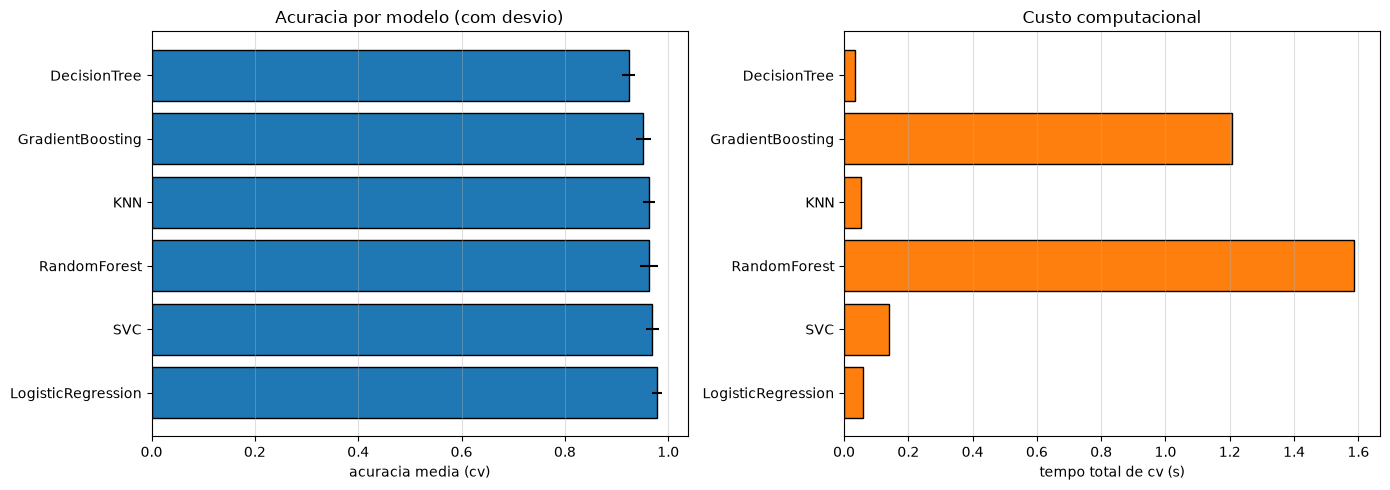

In [10]:
# Visualizacao comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de acuracia CV com desvio
ordem = df_result["modelo"].values
medias = df_result["cv_media"].values
desvios = df_result["cv_desvio"].values

axes[0].barh(ordem, medias, xerr=desvios, color="tab:blue", edgecolor="black")
axes[0].set_xlabel("acuracia media (cv)")
axes[0].set_title("Acuracia por modelo (com desvio)")
axes[0].grid(axis="x", alpha=0.4)

# Tempo de treino
axes[1].barh(ordem, df_result["tempo_cv_s"].values, color="tab:orange", edgecolor="black")
axes[1].set_xlabel("tempo total de cv (s)")
axes[1].set_title("Custo computacional")
axes[1].grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.show()

## Ajuste de hiperparametros com GridSearchCV

Em vez de escolher hiperparametros a mao, testamos combinacoes com
validacao cruzada. O melhor modelo e escolhido pela metrica de CV, nao
pelo conjunto de teste.

In [11]:
from sklearn.model_selection import GridSearchCV

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

grade = {
    "modelo__n_estimators": [100, 200, 400],
    "modelo__max_depth": [None, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
}

busca = GridSearchCV(
    pipe_rf, grade, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1
)
busca.fit(X_train, y_train)

print("Melhores parametros:", busca.best_params_)
print("Melhor acuracia cv:", round(busca.best_score_, 4))

y_pred = busca.predict(X_test)
print("Acuracia no teste:", round(accuracy_score(y_test, y_pred), 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhores parametros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 100}
Melhor acuracia cv: 0.9626
Acuracia no teste: 0.9561


## Comparacao final

Reunimos os melhores modelos, comparamos as metricas no teste e escolhemos
considerando desempenho, custo e interpretabilidade.

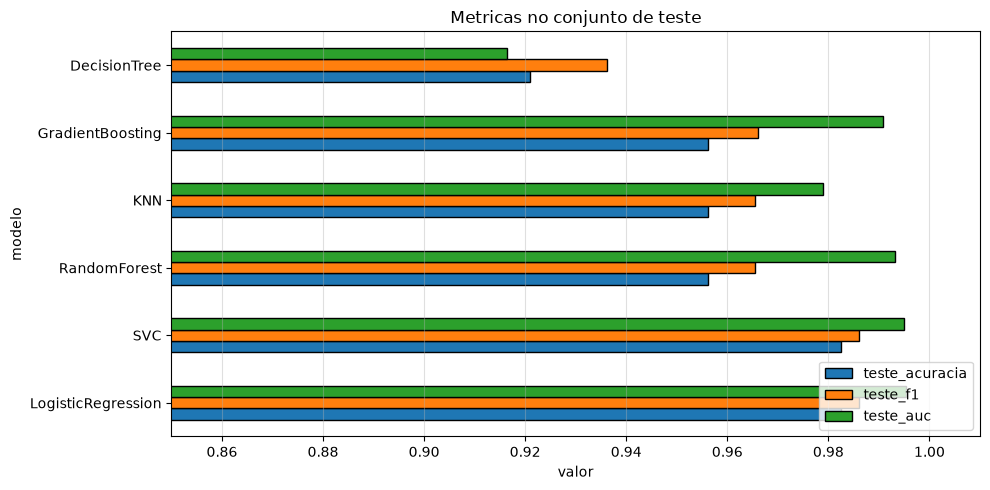

In [12]:
# Comparacao visual das metricas no teste
df_plot = df_result.set_index("modelo")[["teste_acuracia", "teste_f1", "teste_auc"]]

df_plot.plot(kind="barh", figsize=(10, 5), edgecolor="black")
plt.xlabel("valor")
plt.title("Metricas no conjunto de teste")
plt.xlim(0.85, 1.01)
plt.grid(axis="x", alpha=0.4)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Como escolher

Nao existe "melhor modelo universal". Considere:

1. Desempenho: qual tem melhor metrica relevante para o problema
2. Estabilidade: desvio entre folds baixo e bom sinal
3. Custo: tempo de treino e previsao importam em producao
4. Interpretabilidade: as vezes um modelo simples e exigido
5. Manutencao: modelo complexo exige mais cuidado ao longo do tempo

Em muitos casos, LogisticRegression ou RandomForest bem ajustados ja
resolvem. Só parta para modelos mais complexos quando houver ganho claro.

## Exercicios

1. Adicione GradientBoosting e XGBoost (se instalado) a comparacao.
2. Faca GridSearchCV para LogisticRegression variando C e penalty.
3. Compare tempo de treino e acuracia. Vale o custo?
4. Repita todo o fluxo para o dataset wine e tire conclusoes.
5. Escolha um modelo final e escreva um paragrafo justificando a escolha.